In [461]:
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from src.etl import ETL
from src.settings.pipeline import pipeline_settings

In [462]:
BASE_PATH: Path = Path.cwd()
RANDOM_SEED: float = 0

sns.set_theme(style="darkgrid", palette="dark")

In [463]:
df_raw: pl.DataFrame = pl.read_csv(
    BASE_PATH / 'data' / 'raw' / 'raw_mock_sales_data.csv',
    schema_overrides = {
        'SaleDate': pl.String,
        'ProductID': pl.String,
        'ASP': pl.String,
        'QT': pl.String,
    }
)

In [464]:
df_raw.head(5)

SaleDate,ProductID,ASP,QT
str,str,str,str
"""2024-02-11""","""P003""","""46.11""","""3.0"""
"""2025-04-20""","""P007""","""50.76""","""3.0"""
"""07/04/2025""","""P001""","""122.77""","""5.0"""
"""2020-02-14""","""P004""","""98.75""","""6.0"""
"""2022-06-28""","""P010""","""51.81""","""3.0"""


In [465]:
df_raw.describe()

statistic,SaleDate,ProductID,ASP,QT
str,str,str,str,str
"""count""","""200174""","""200151""","""200175""","""200174"""
"""null_count""","""126""","""149""","""125""","""126"""
"""mean""",null,null,null,null
"""std""",null,null,null,null
"""min""","""01-03-2024""",""" P001 ""","""$10.00""","""-1.0"""
"""25%""",null,null,null,null
"""50%""",null,null,null,null
"""75%""",null,null,null,null
"""max""","""31/05/2026""","""product_1""","""9980.0""","""99.0"""


In [466]:
def get_inconsistencies(df: pl.DataFrame, column: str, store: bool) -> pl.DataFrame | None:
    inconsistencies_df: pl.DataFrame = pl.DataFrame()

    if column == 'SaleDate':
        inconsistencies_df: pl.DataFrame = df.with_columns(
            pl.col(column).str.to_date(format='%Y-%m-%d', strict=False).is_null().alias('inconsistent'),
        ).filter(
            pl.col('inconsistent') == True
        )

    if column == 'ProductID':
        inconsistencies_df: pl.DataFrame = df.with_columns(
            ~pl.col(column).str.contains(r"^P\d{3}$").alias('inconsistent'),
        ).filter(
            pl.col('inconsistent') == True
        )

    if column in ['QT', 'ASP']:
        inconsistencies_df: pl.DataFrame = df.with_columns(
            (
                (pl.col(column).cast(pl.Float64, strict=False) <= 0) |
                (pl.col(column).cast(pl.Float64, strict=False).is_null())
            ).alias('inconsistent'),
        ).filter(
            pl.col('inconsistent') == True
        )

    inconsistencies_path: Path = BASE_PATH / 'exploratory_output' / 'inconsistencies'

    if len(inconsistencies_df) > 0 and store:
        inconsistencies_df.write_csv(
            inconsistencies_path / f'inconsistencies_{column}.csv',
            separator=';'
        )

        return inconsistencies_df
    return None

In [467]:
for column in df_raw.columns:
    inconsistencies_df: pl.DataFrame = get_inconsistencies(df_raw, column, True)

    size: int | None = len(inconsistencies_df) if inconsistencies_df is not None else 0
    print(f'Column {column} inconsistencies: {size}')

Column SaleDate inconsistencies: 526
Column ProductID inconsistencies: 299
Column ASP inconsistencies: 575
Column QT inconsistencies: 576


In [468]:
allowed_date_formats: list = [
    "%Y-%m-%d",    # 2025-12-01
    "%d/%m/%Y",    # 01/12/2025
    "%m-%d-%Y",    # 12-01-2026
    "%Y%m%d",      # 20251201
    "%d-%b-%Y",    # 01-Dec-2025
]

df_cleaned = (df_raw
    .filter(
        ~pl.col('ProductID').is_in(['UNKNOWN', '#REF!', 'N/A', 'P00O', 'null']),
        pl.col('ProductID') != 'P999',
        pl.col('ProductID').is_not_null(),
        pl.col('SaleDate').is_not_null(),
    )

    .with_columns(
        pl.coalesce([
            pl.col('SaleDate').str.to_date(format=date_format, strict=False)
            for date_format in allowed_date_formats
        ]).alias('SaleDate')
    )

    .with_columns(
        pl.col('ProductID').str.strip_chars().alias('ProductID')
    )

    .with_columns(
        pl.when(
            pl.col('ProductID').str.starts_with('p')
        ).then(
            pl.col('ProductID').str.replace('p', 'P')
        ).otherwise('ProductID').alias('ProductID')
    )

    .with_columns(
        pl.when(
            pl.col('ProductID').str.starts_with('Product')
        ).then(
            pl.col('ProductID').str.replace('Product', 'P')
        ).otherwise('ProductID').alias('ProductID')
    )

    .with_columns(
        pl.when(
            pl.col('ProductID') == 'P_1'
        ).then(
            pl.lit('P001')
        ).otherwise('ProductID').alias('ProductID')
    )

    .with_columns(
        pl.col('ASP').str.replace('$', '', literal=True).alias('ASP')
    )

    .with_columns(
        pl.when(
            pl.col('QT').cast(pl.Float64, strict=False) < 0
        ).then(
            - pl.col('QT').cast(pl.Float64, strict=False)
        ).otherwise('QT').alias('QT'),
        pl.when(
            pl.col('ASP').cast(pl.Float64, strict=False) < 0
        ).then(
            - pl.col('ASP').cast(pl.Float64, strict=False)
        ).otherwise('ASP').alias('ASP'),
    )

    .with_columns(
        pl.col('QT').cast(pl.Float64),
        pl.col('ASP').cast(pl.Float64)
    )
)

df_cleaned = (
    df_cleaned
    .sort(["ProductID", "SaleDate"])

    .with_columns(
        pl.col("ASP").forward_fill().over("ProductID"),
    )

    .with_columns(
        pl.col("ASP").backward_fill().over("ProductID"),
    )

    .with_columns(
        pl.col("QT").interpolate("linear").over("ProductID"),
    )

    .with_columns(
        pl.col("QT").fill_null(pl.col("QT").median().over("ProductID")),
    )
)

df_cleaned = df_cleaned.filter(
    pl.col('SaleDate') < dt.date(dt.date.today().year, dt.date.today().month, 1)
)

df_cleaned_test: pl.DataFrame = df_cleaned
for column in df_cleaned.columns:
    df_cleaned_test = df_cleaned_test.with_columns(
        pl.col(column).cast(pl.String)
    )

In [469]:
for column in df_cleaned_test.columns:
    inconsistencies_df: pl.DataFrame = get_inconsistencies(df_cleaned_test, column, False)

    size: int = len(inconsistencies_df) if inconsistencies_df is not None else 0
    print(f'Column {column} inconsistencies: {size}')

Column SaleDate inconsistencies: 0
Column ProductID inconsistencies: 0
Column ASP inconsistencies: 0
Column QT inconsistencies: 0


In [470]:
df_cleaned

SaleDate,ProductID,ASP,QT
date,str,f64,f64
2020-01-01,"""P001""",96.58,21.0
2020-01-01,"""P001""",97.77,13.0
2020-01-01,"""P001""",97.11,12.0
2020-01-01,"""P001""",97.23,12.0
2020-01-01,"""P001""",97.26,16.0
…,…,…,…
2026-06-17,"""P010""",47.72,14.0
2026-06-17,"""P010""",47.43,30.0
2026-06-17,"""P010""",47.68,19.0


In [471]:
df_cleaned.describe()

statistic,SaleDate,ProductID,ASP,QT
str,str,str,f64,f64
"""count""","""199756""","""199756""",199756.0,199756.0
"""null_count""","""0""","""0""",0.0,0.0
"""mean""","""2023-04-30 17:32:35.097218""",null,69.080843,12.292229
"""std""",null,null,148.065141,125.783467
"""min""","""2020-01-01""","""P001""",0.09,0.0
"""25%""","""2021-09-27""",null,45.73,4.0
"""50%""","""2023-05-19""",null,61.64,8.0
"""75%""","""2024-12-10""",null,98.37,14.0
"""max""","""2026-06-17""","""P010""",12816.0,15500.0


In [472]:
df_cleaned = df_cleaned.filter(
    pl.col('SaleDate') < pipeline_settings.end_date 
)

In [473]:
df_cleaned = df_cleaned.with_columns(
    pl.col('SaleDate').dt.year().alias('Y'),
    pl.col('SaleDate').dt.month().alias('M')
).rename({
    'SaleDate': 'ds',
    'ProductID': 'SKU'
})

In [474]:
def line_plot(df: pl.DataFrame, x: str, y: str, title: str, hue: str | None = None) -> None:
    fig, ax = plt.subplots(figsize=(18, 6))
    fig.suptitle(title)
    sns.lineplot(data=df, x=x, y=y, hue=hue, ax=ax)
    plt.show()

In [475]:
for target in pipeline_settings.targets:
    window: int = 31

    df_cleaned = (
        df_cleaned
        .sort(['SKU', 'ds'])
        .with_columns(
            pl.col(target).rolling_median(window_size=window, min_samples=1).over('SKU').alias(f'{target}_rolling_median'),
        )

        .with_columns(
            (pl.col(target) - pl.col(f'{target}_rolling_median')).abs().rolling_median(window_size=window, min_samples=1).over('SKU').alias(f'{target}_rolling_mad')
        )

        .with_columns(
            (((pl.col(target) - pl.col(f'{target}_rolling_median')) / (pl.col(f'{target}_rolling_mad') * 1.4826)).abs() > 3).alias(f'{target}_outlier'))
    )

df_full: pl.DataFrame = df_cleaned

df_cleaned = df_cleaned.filter(~pl.col('ASP_outlier') & ~pl.col('QT_outlier'))

In [476]:
df_cleaned.write_csv(BASE_PATH / 'data' / 'cleaned' / 'cleaned_sales_data.csv')
df_cleaned

ds,SKU,ASP,QT,Y,M,QT_rolling_median,QT_rolling_mad,QT_outlier,ASP_rolling_median,ASP_rolling_mad,ASP_outlier
date,str,f64,f64,i32,i8,f64,f64,bool,f64,f64,bool
2020-01-01,"""P001""",97.77,13.0,2020,1,17.0,2.0,false,97.175,0.2975,false
2020-01-01,"""P001""",97.23,12.0,2020,1,12.5,0.75,false,97.17,0.03,false
2020-01-01,"""P001""",97.26,16.0,2020,1,13.0,1.0,false,97.23,0.03,false
2020-01-02,"""P001""",96.96,8.0,2020,1,12.5,2.75,false,97.17,0.135,false
2020-01-02,"""P001""",97.3,6.0,2020,1,12.0,3.0,false,97.23,0.07,false
…,…,…,…,…,…,…,…,…,…,…,…
2026-02-28,"""P010""",48.43,6.0,2026,2,10.0,4.0,false,48.37,0.47,false
2026-02-28,"""P010""",47.81,4.0,2026,2,10.0,4.0,false,48.37,0.47,false
2026-02-28,"""P010""",48.63,15.0,2026,2,11.0,4.0,false,48.4,0.43,false


In [477]:
df_QT_featurized: pd.DataFrame = ETL.featurize(target='QT', cleaned_data_df=df_cleaned, store=True, files_path=BASE_PATH)
df_ASP_featurized: pd.DataFrame = ETL.featurize(target='ASP', cleaned_data_df=df_cleaned, store=True, files_path=BASE_PATH)

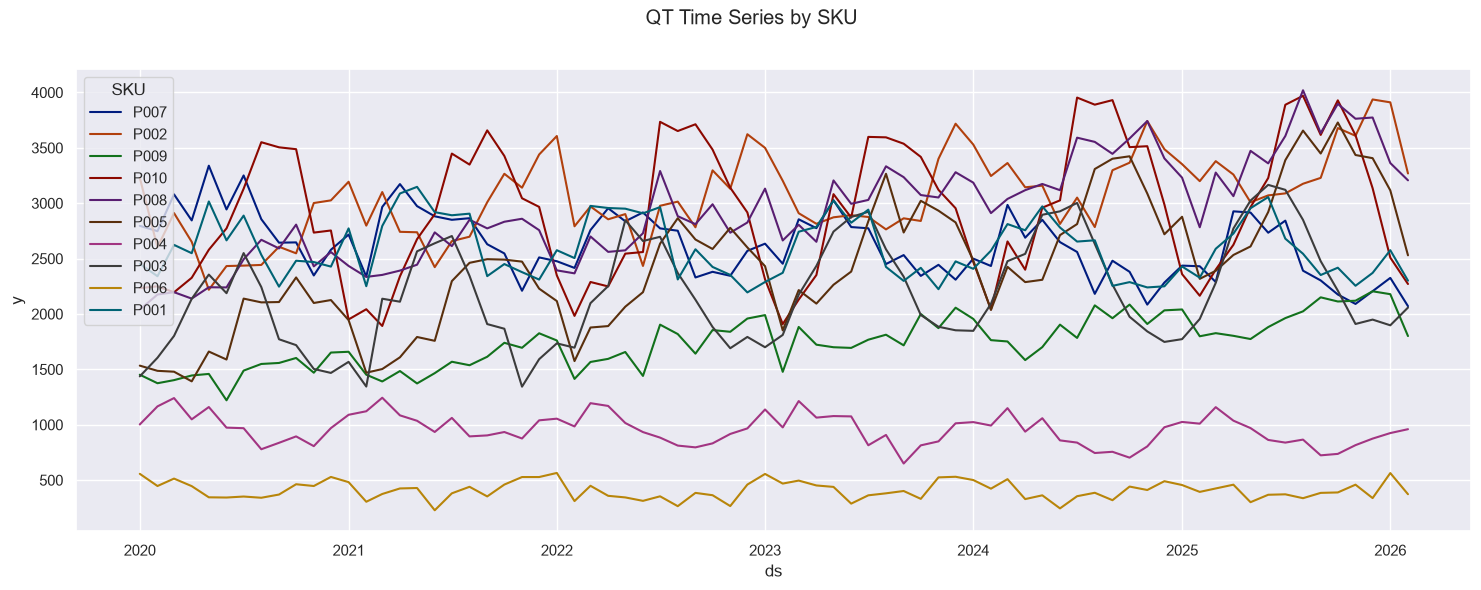

In [478]:
line_plot(df_QT_featurized, x='ds', y='y', hue='SKU', title=f'QT Time Series by SKU')

In [479]:
def add_noise(target: str, noiseless_df: pl.DataFrame, noise_multiplier: float) -> pl.DataFrame:
    noise: np.ndarray = np.random.default_rng(RANDOM_SEED).normal(1.0, noise_multiplier, len(noiseless_df))

    return noiseless_df.with_columns(
        (pl.col(target) * pl.Series('noise', noise)).round(2).alias(target)
    )

In [480]:
for target in pipeline_settings.targets:
    df_featurized_with_noise = add_noise(target, df_featurized, 0.1)

AttributeError: 'DataFrame' object has no attribute 'with_columns'

In [ ]:

df_in: pl.DataFrame = df_featurized_with_noise.filter(
    pl.col('SKU') == product
).select(
    ['SKU', 'ds', target]
).rename({
    target: 'y'
})

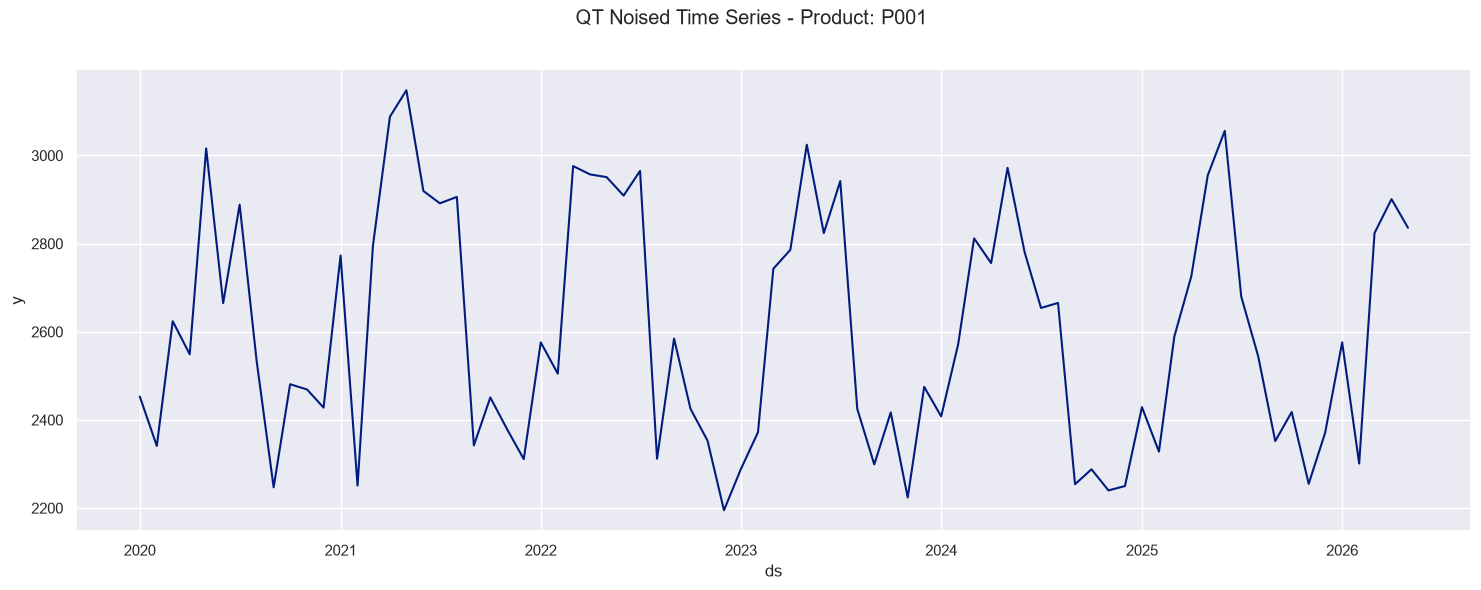

In [ ]:
line_plot(df_in, x='ds', y='y', title=f'{target} Noised Time Series - Product: {product}')

In [ ]:
df_in: pd.DataFrame = df_in.to_pandas()
df_in['ds'] = pd.to_datetime(df_in['ds'])

In [ ]:
from statsmodels.tsa.seasonal import STL, DecomposeResult

def components_plot(df: pd.DataFrame, product: str, target: str) -> None:
    components_colors: dict[str, str] = {
        'Observed': 'grey',
        'Trend': 'blue',
        'Seasonality': 'red',
        'Residual': 'orange',
    }

    fig, axes = plt.subplots(
        figsize = (22, 4),
        nrows = 1,
        ncols = 4,
    )

    fig.suptitle(f'{target} STL Decomposition - Product: {product}', fontsize=16, fontweight='bold')

    product_series: pd.Series = (
        df
        .set_index('ds')['y']
        .asfreq('MS')
    )
    stl: STL = STL(product_series, period=12, robust=True)
    result: DecomposeResult = stl.fit()

    components: dict[str, pd.Series] = {
        'Observed': product_series,
        'Trend': result.trend,
        'Seasonality': result.seasonal,
        'Residual': result.resid
    }

    for col_idx, (component_name, component_series) in enumerate(components.items()):
        axes[col_idx].set_title(
            component_name,
            fontsize = 14,
            fontweight = 'bold',
        )
        ax = axes[col_idx]

        if component_name in ('Seasonality', 'Residual'):
            ax.axhline(0, color='grey', linewidth=1, linestyle='--', alpha=0.6)

        if component_name == 'Residual':
            sns.scatterplot(
                x = component_series.index,
                y = component_series.values,
                ax = ax,
                color = components_colors[component_name],
            )
        else:
            sns.lineplot(
                x = component_series.index,
                y = component_series.values,
                ax = ax,
                color = components_colors[component_name],
            )

        ax.tick_params(axis='y', labelsize=9, left=True, labelleft=True)

        for spine in ax.spines.values():
                spine.set_linewidth(0.8)
                spine.set_color('grey')

    plt.tight_layout()
    plt.show()

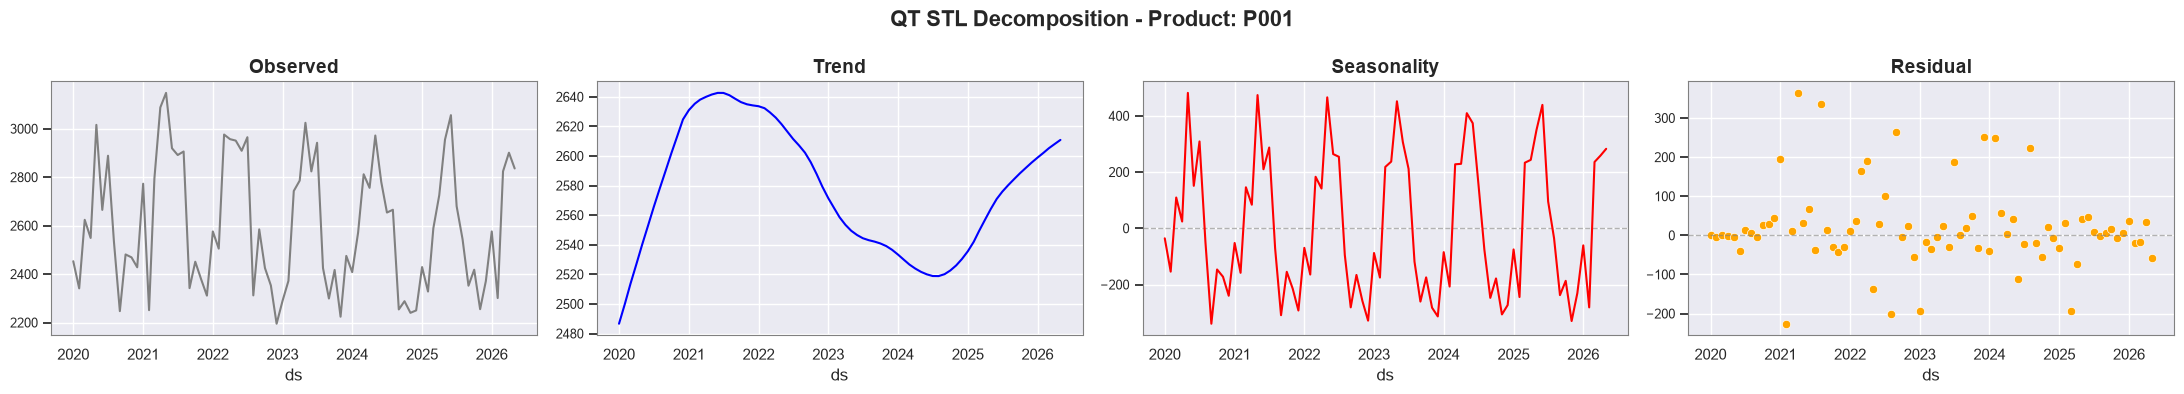

In [ ]:
components_plot(df_in, product, target)

In [ ]:
def seasonal_plot(df: pd.DataFrame, product: str, target: str) -> None:
    fig, _ = plt.subplots(figsize=(22, 4))
    fig.suptitle(f'{target} Seasonal plot - Product: {product}', fontsize=16, fontweight="bold")

    sns.lineplot(
        data = df,
        x = 'month',
        y = 'y',
        hue = 'year',
        marker = 'o',
        palette='hls'
    )

    plt.tight_layout()

In [ ]:
def month_boxplot(df: pd.DataFrame, product: str, target: str) -> None:
    fig, _ = plt.subplots(figsize=(22, 4))
    fig.suptitle(f'{target} Month boxplot - Product {product}', fontsize=16, fontweight="bold")

    sns.boxplot(
        data = df,
        x = 'month',
        y = 'y'
    )

    plt.tight_layout()

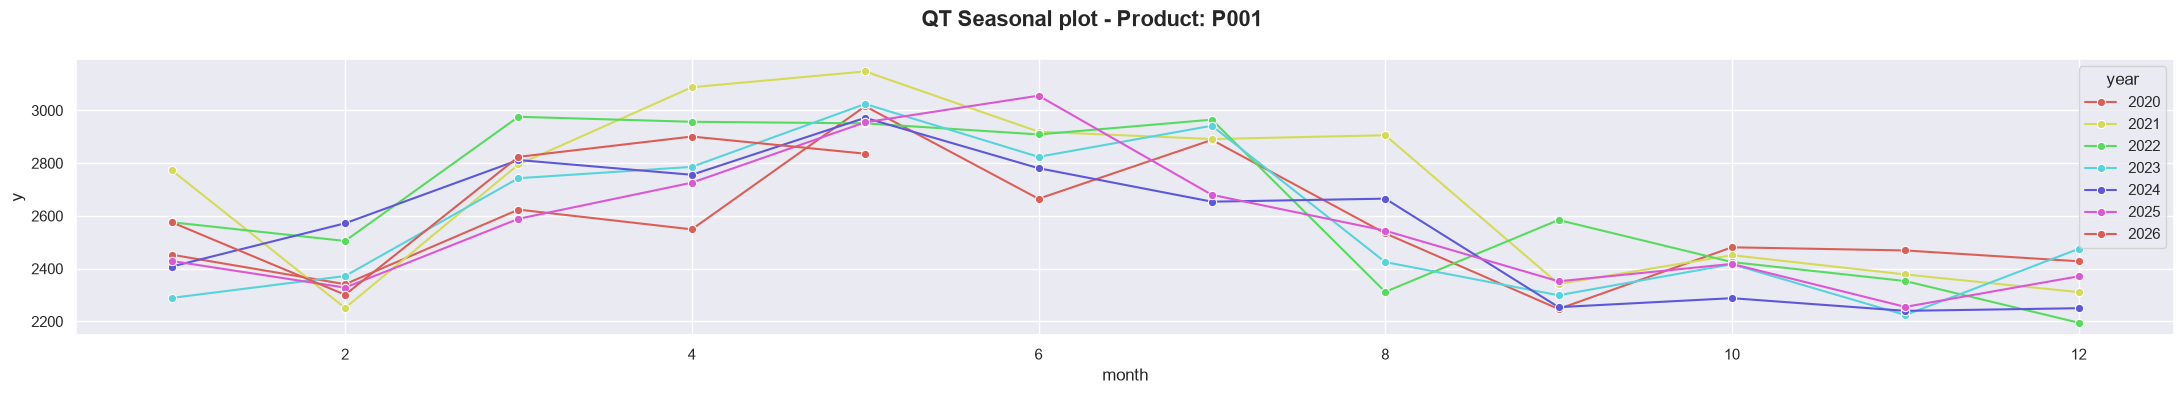

In [ ]:
df_seasonal: pd.DataFrame = df_in.copy()
df_seasonal['month'] = df_seasonal['ds'].dt.month
df_seasonal['year'] = df_seasonal['ds'].dt.year

seasonal_plot(df_seasonal, product, target)

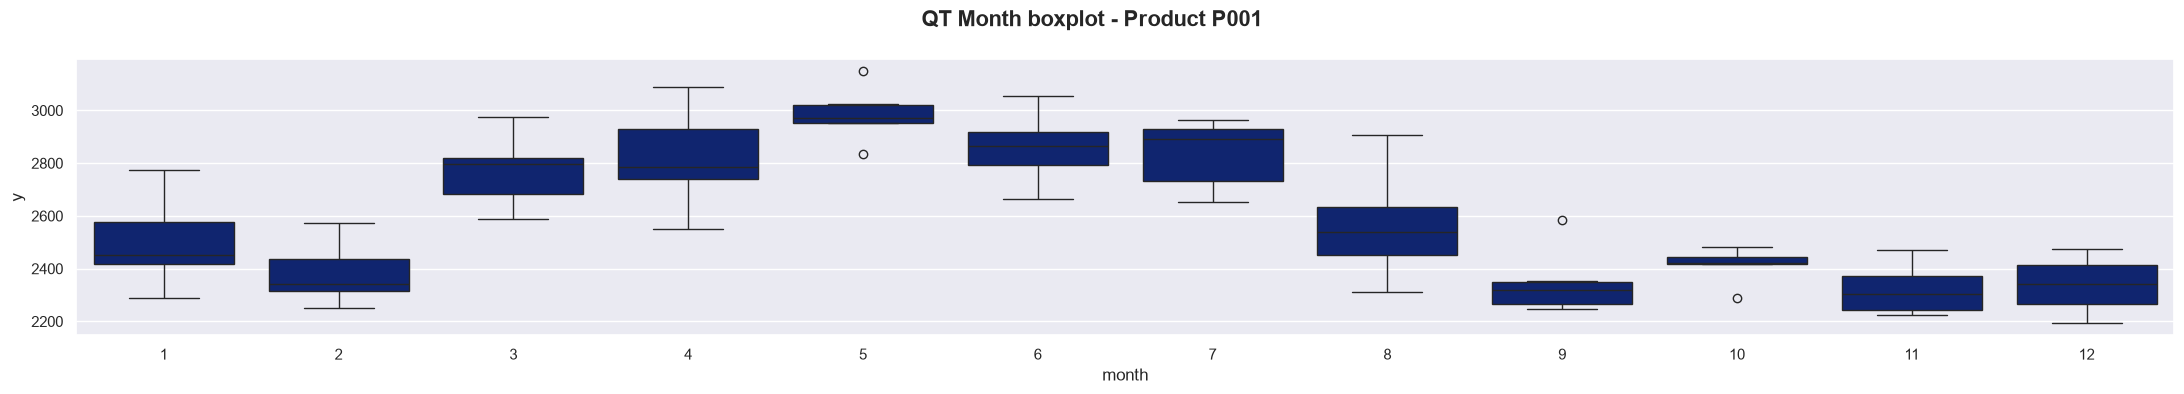

In [ ]:
month_boxplot(df_seasonal, product, target)

In [ ]:
df_in.to_csv(BASE_PATH / 'data' / 'featurized' / f'featurized_{product}_{target}_data.csv', sep=';', index=False)